In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, cohen_kappa_score, precision_score, recall_score
from sklearn.model_selection import KFold

In [2]:
LABEL_DICT = {
    "Sleep stage W": 0,
    "Sleep stage 1": 1,
    "Sleep stage 2": 2,
    "Sleep stage 3": 3,
    "Sleep stage 4": 3, # Usually N3 and N4 are merged
    "Sleep stage R": 4,
}
CLASS_LABELS = {
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "R": 4
}

In [3]:
def plot_results(y_true, y_pred, histories):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 1. Plot Training/Validation Curves (Averaged over folds)
    plt.figure(figsize=(12, 5))
    
    # Average the losses across all folds for a cleaner plot
    avg_train_loss = np.mean([fh['train_loss'] for fh in histories], axis=0)
    avg_val_loss = np.mean([fh['val_loss'] for fh in histories], axis=0)
    
    score_reports = {
        "accuracy": [np.mean(fh['val_acc']) for fh in histories],
        "f1": [np.mean(fh['val_f1']) for fh in histories],
        "kappa": [np.mean(fh['val_kappa']) for fh in histories],
    }
    
    plt.subplot(1, 2, 1)
    plt.plot(avg_train_loss, label='Avg Train Loss')
    plt.plot(avg_val_loss, label='Avg Val Loss')
    plt.title('Cross-Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # 2. Confusion Matrix Plot
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true, y_pred)
    # Normalize CM to see percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_LABELS.keys(), 
                yticklabels=CLASS_LABELS.keys())
    plt.title('Aggregated Normalized Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('cv_performance_results.png')
    plt.show()

    # 3. Print Comprehensive Scores
    print("\n" + "="*30)
    print("FINAL 10-FOLD CV RESULTS")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=list(CLASS_LABELS.keys())))
    
    # 4. Report fold scores
    report_df = pd.DataFrame(score_reports, index=[f"fold {i + 1}" for i in range(len(histories))])
    print(f"\n\nFolds Score Report Summary")
    print(report_df)

In [4]:
class SleepSpectroNet(nn.Module):
    def __init__(self, num_classes=5, window_size=5, embed_dim=128):
        super(SleepSpectroNet, self).__init__()
        
        # 1. STFT Parameters
        # n_fft=256 at 100Hz gives good frequency resolution for sleep bands
        self.n_fft = 256
        self.hop_length = 64 
        
        # 2. 2D CNN Feature Extractor (Processes the Spectrogram)
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # Reduces size
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveMaxPool2d((8, 8)), # Force to a fixed size
            nn.Flatten()
        )
        
        # CNN output size is 64 filters * 8 * 8 = 4096. 
        # We project this down to our embedding dimension.
        self.projection = nn.Linear(4096, embed_dim)
        
        # 3. Temporal Context (Attention)
        self.pos_embedding = nn.Parameter(torch.randn(1, window_size, embed_dim))
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)
        
        # 4. Classifier
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x shape: (Batch, Win_Size, 1, Time=3000)
        B, W, C, T = x.shape
        
        # Collapse Batch and Window to process all epochs through STFT/CNN
        x = x.view(B * W, T) 
        
        # --- Frequency Domain Transformation ---
        # Generate Spectrogram: (B*W, Freq_Bins, Time_Steps)
        # We take the magnitude of the complex STFT output
        stft = torch.stft(x, n_fft=self.n_fft, hop_length=self.hop_length, 
                          return_complex=True, window=torch.hann_window(self.n_fft).to(x.device))
        spectrogram = torch.abs(stft).unsqueeze(1) # Add channel dim: (B*W, 1, F, T_s)
        
        # Log-scale power is usually better for neural nets
        spectrogram = torch.log1p(spectrogram)
        
        # --- Feature Extraction ---
        features = self.feature_extractor(spectrogram) # (B*W, 4096)
        x = self.projection(features) # (B*W, 128)
        
        # --- Temporal Attention ---
        x = x.view(B, W, 128) # Back to sequence
        x = x + self.pos_embedding
        
        attn_out, _ = self.attention(x, x, x)
        
        # Classify the middle epoch
        out = self.classifier(attn_out[:, W // 2, :])
        return out

In [ ]:
class SleepSatelighteModel(nn.Module):
    def __init__(self, num_classes=5, window_size=5, embed_dim=128):
        super(SleepSatelighteModel, self).__init__()
        
        

In [5]:
class SleepCenteredWindowDataset(Dataset):
    def __init__(self, file_paths, window_size=5, trim_margin_min=30):
        """
        window_size: must be odd (e.g., 5, 9, 21)
        """
        assert window_size % 2 != 0, "Window size must be an odd number."
        self.window_size = window_size
        self.half_win = window_size // 2
        self.features = []
        self.labels = []
        
        margin = (trim_margin_min * 60) // 30
        
        for path in file_paths:
            with np.load(path) as data:
                x, y = data['x'], data['y']
                
                # 1. Trimming based on sleep activity
                sleep_idx = np.where(y != 0)[0]
                if len(sleep_idx) == 0: continue
                start, end = max(0, sleep_idx[0]-margin), min(len(y), sleep_idx[-1]+margin+1)
                x, y = x[start:end], y[start:end]
                
                # 2. Subject-level Z-score Normalization
                x = (x - np.mean(x)) / (np.std(x) + 1e-8)
                
                # 3. Sliding Centered Window
                # We start from half_win and end at len - half_win
                for i in range(self.half_win, len(x) - self.half_win):
                    # Extract [i-2, i-1, i, i+1, i+2] if window_size is 5
                    window = x[i - self.half_win : i + self.half_win + 1]
                    self.features.append(window)
                    self.labels.append(y[i]) # Label of the middle epoch

        # Stack into tensors
        self.X = torch.from_numpy(np.array(self.features)).float()
        self.Y = torch.from_numpy(np.array(self.labels)).long()

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [6]:
class SleepSubjectDataset(Dataset):
    def __init__(self, file_paths, trim_margin_min=30):
        self.samples = []
        self.labels = []
        margin = (trim_margin_min * 60) // 30
        
        for path in file_paths:
            with np.load(path) as data:
                x, y = data['x'], data['y']
                # Trimming logic
                sleep_idx = np.where(y != 0)[0]
                if len(sleep_idx) > 0:
                    start, end = max(0, sleep_idx[0]-margin), min(len(y), sleep_idx[-1]+margin+1)
                    x, y = x[start:end], y[start:end]
                    
                    # Normalize per subject (Z-score)
                    x = (x - np.mean(x)) / (np.std(x) + 1e-8)
                    
                    self.samples.append(torch.from_numpy(x).float())
                    self.labels.append(torch.from_numpy(y).long())

        # Flatten for the DataLoader, but we kept them separate during loading
        self.X = torch.cat(self.samples, dim=0)
        self.Y = torch.cat(self.labels, dim=0)

    def __len__(self): return len(self.Y)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

In [7]:
class Trainer:
    def __init__(self, model, device, fold_idx):
        self.model = model.to(device)
        self.device = device
        self.fold_idx = fold_idx
        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    def train_epoch(self, loader, optimizer, criterion):
        self.model.train()
        total_loss = 0
        for x, y in loader:
            x, y = x.to(self.device), y.to(self.device)
            optimizer.zero_grad()
            out = self.model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def validate(self, loader, criterion):
        self.model.eval()
        total_loss = 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                out = self.model(x)
                loss = criterion(out, y)
                total_loss += loss.item()
                preds = out.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                
        avg_loss = total_loss / len(loader)
        scores = {
            "accuracy": accuracy_score(all_labels, all_preds),
            "f1": f1_score(all_labels, all_preds, average='macro'),
            "precision": precision_score(all_labels, all_preds, average='macro'),
            "recall": recall_score(all_labels, all_preds, average='macro'),
            "kappa": cohen_kappa_score(all_labels, all_preds)
        }
        return avg_loss, scores, all_preds, all_labels

    def save_checkpoint(self, val_loss):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            torch.save(self.model.state_dict(), f"checkpoints/best_model_fold_{self.fold_idx}.pt")

In [ ]:
def run_kfold(window_size=5):
    data_path = "/home/kasra/courses/2026-edge-computing/project/dataset/sleepEDF/processed/SC"
    all_files = np.array(sorted(glob.glob(os.path.join(data_path, "*.npz"))))
    
    # Define 10-fold cross-validation on files (subjects)
    n_folds = 5
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Storage for overall metrics
    all_fold_preds = []
    all_fold_labels = []
    fold_histories = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(all_files)):
        print(f"\n{'='*20} Fold {fold+1}/{n_folds} {'='*20}")
        
        # 1. Initialize Datasets (Subject-wise split)
        train_ds = SleepCenteredWindowDataset(all_files[train_idx], window_size=window_size)
        val_ds = SleepCenteredWindowDataset(all_files[val_idx], window_size=window_size)
        
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

        # 2. Setup Model, Loss (Weighted), and Optimizer
        model = SleepSpectroNet(num_classes=5).to(device)
        
        # Compute class weights for this fold to handle imbalance
        counts = np.bincount(train_ds.Y.numpy())
        weights = 1.0 / torch.tensor(counts, dtype=torch.float32).to(device)
        criterion = torch.nn.CrossEntropyLoss(weight=weights)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
        # 3. Training/Validation Loop
        trainer = Trainer(model, device, fold) # Uses the Trainer class from previous step
        fold_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_kappa': []}
        best_fold_preds = None
        best_fold_labels = None

        for epoch in range(20):  # Adjust epochs as needed
            t_loss = trainer.train_epoch(train_loader, optimizer, criterion)
            v_loss, v_scores, preds, labels = trainer.validate(val_loader, criterion)
            scheduler.step(v_loss)
            
            fold_history['train_loss'].append(t_loss)
            fold_history['val_loss'].append(v_loss)
            fold_history['val_acc'].append(v_scores["accuracy"])
            fold_history['val_f1'].append(v_scores["f1"])
            fold_history['val_kappa'].append(v_scores["kappa"])
            
            # Checkpoint: Save if best val_loss
            if v_loss < trainer.best_val_loss:
                trainer.best_val_loss = v_loss
                torch.save(model.state_dict(), f"checkpoints/best_model_fold_{fold}.pt")
                best_fold_preds = preds
                best_fold_labels = labels
            
            if epoch % 5 == 0:
                print(f"Epoch {epoch:02d} | T-Loss: {t_loss:.4f} | V-Loss: {v_loss:.4f} | V-Acc: {v_scores["accuracy"]:.2f} | V-kappa: {v_scores["kappa"]:.2f}")

        # Store results for this fold
        all_fold_preds.extend(best_fold_preds)
        all_fold_labels.extend(best_fold_labels)
        fold_histories.append(fold_history)

    # 4. Final Analysis and Plotting5
    plot_results(all_fold_labels, all_fold_preds, fold_histories)


==================== Fold 1/5 ====================
Epoch 00 | T-Loss: 0.8218 | V-Loss: 0.7289 | V-Acc: 0.69 | V-kappa: 0.60
Epoch 05 | T-Loss: 0.6527 | V-Loss: 0.6829 | V-Acc: 0.73 | V-kappa: 0.65
Epoch 10 | T-Loss: 0.6279 | V-Loss: 0.7179 | V-Acc: 0.73 | V-kappa: 0.65
Epoch 15 | T-Loss: 0.5793 | V-Loss: 0.6217 | V-Acc: 0.74 | V-kappa: 0.67

==================== Fold 2/5 ====================
Epoch 00 | T-Loss: 0.8260 | V-Loss: 0.8283 | V-Acc: 0.64 | V-kappa: 0.54
Epoch 05 | T-Loss: 0.7056 | V-Loss: 0.7962 | V-Acc: 0.66 | V-kappa: 0.56
Epoch 10 | T-Loss: 0.6489 | V-Loss: 0.7246 | V-Acc: 0.71 | V-kappa: 0.62
Epoch 15 | T-Loss: 0.6244 | V-Loss: 0.7437 | V-Acc: 0.69 | V-kappa: 0.60

==================== Fold 3/5 ====================
Epoch 00 | T-Loss: 0.8282 | V-Loss: 0.7908 | V-Acc: 0.69 | V-kappa: 0.60
Epoch 05 | T-Loss: 0.6820 | V-Loss: 0.7107 | V-Acc: 0.70 | V-kappa: 0.61
Epoch 10 | T-Loss: 0.6549 | V-Loss: 0.7469 | V-Acc: 0.70 | V-kappa: 0.61
Epoch 15 | T-Loss: 0.6091 | V-Loss: 0.765

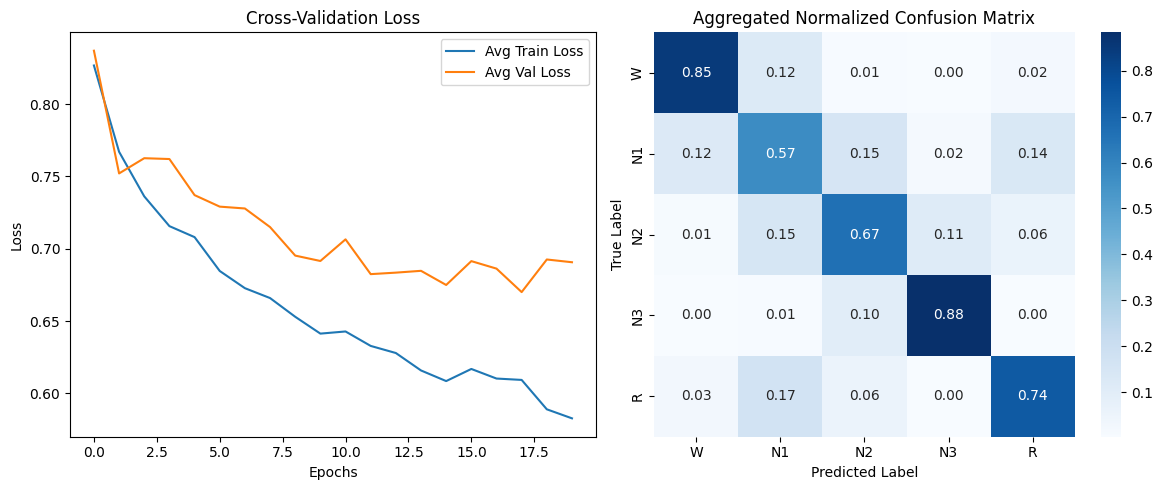


FINAL 10-FOLD CV RESULTS
              precision    recall  f1-score   support

           W       0.93      0.85      0.89     65341
          N1       0.35      0.57      0.43     21520
          N2       0.88      0.67      0.76     69132
          N3       0.57      0.88      0.69     13039
           R       0.69      0.74      0.72     25835

    accuracy                           0.74    194867
   macro avg       0.68      0.74      0.70    194867
weighted avg       0.79      0.74      0.76    194867



Folds Score Report Summary
        accuracy        f1     kappa
fold 1  0.736074  0.700542  0.654456
fold 2  0.689274  0.658704  0.596671
fold 3  0.719935  0.665617  0.630565
fold 4  0.710569  0.652450  0.615247
fold 5  0.727639  0.662521  0.636912


In [12]:
if __name__ == "__main__":
    # This ensures that child workers don't execute run_kfold() again
    run_kfold(window_size=5)

## DEBUG

In [ ]:
margin = (30 * 60) // 30
samples = []
labels = []
data_path = "/home/kasra/courses/2026-edge-computing/project/dataset/sleepEDF/processed/SC"
file_paths = np.array(glob.glob(os.path.join(data_path, "*.npz")))

for path in file_paths:
    with np.load(path) as data:
        x, y = data['x'], data['y']
        # Trimming logic
        sleep_idx = np.where(y != 0)[0]
        if len(sleep_idx) > 0:
            start, end = max(0, sleep_idx[0]-margin), min(len(y), sleep_idx[-1]+margin+1)
            x, y = x[start:end], y[start:end]
            
            # Normalize per subject (Z-score)
            x = (x - np.mean(x)) / (np.std(x) + 1e-8)
            
            samples.append(torch.from_numpy(x).float())
            labels.append(torch.from_numpy(y).long())

# Flatten for the DataLoader, but we kept them separate during loading
X = torch.cat(samples, dim=0)
Y = torch.cat(labels, dim=0)

In [ ]:
X.shape

torch.Size([195479, 1, 3000])